In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

In [2]:
df = pd.read_csv('drug200.csv')

In [3]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [6]:
print(df['Sex'].value_counts())
print('-----')
print(df['BP'].value_counts())
print('-----')
print(df['Cholesterol'].value_counts())
print('-----')
print(df['Drug'].value_counts())

Sex
M    104
F     96
Name: count, dtype: int64
-----
BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64
-----
Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64
-----
Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


sex -> label encoder
BP -> ordinal encoding
Cholesterol -> label encoder
drug -> label encoder

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

In [10]:
df['BP'] = df['BP'].map({
    'LOW' : 0,
    'NORMAL': 1,
    'HIGH':2
})

In [11]:
df['Cholesterol'] = df['Cholesterol'].map({
    'NORMAL': 0,
    'HIGH': 1
})

In [12]:
print(df['Sex'].value_counts())
print('-----')
print(df['BP'].value_counts())
print('-----')
print(df['Cholesterol'].value_counts())
print('-----')
print(df['Drug'].value_counts())

Sex
1    104
0     96
Name: count, dtype: int64
-----
BP
2    77
0    64
1    59
Name: count, dtype: int64
-----
Cholesterol
1    103
0     97
Name: count, dtype: int64
-----
Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


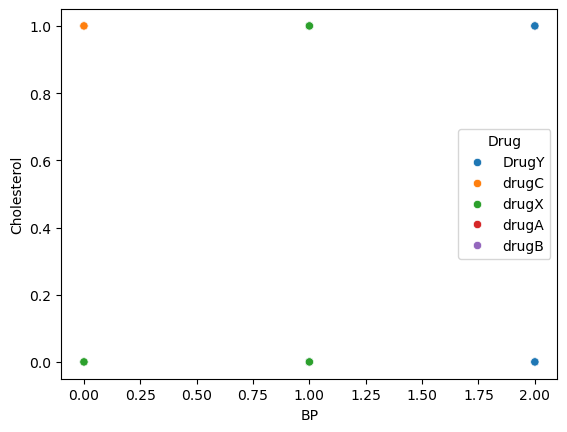

In [13]:
sns.scatterplot(x=df["BP"], y=df["Cholesterol"], hue=df["Drug"])
plt.show()

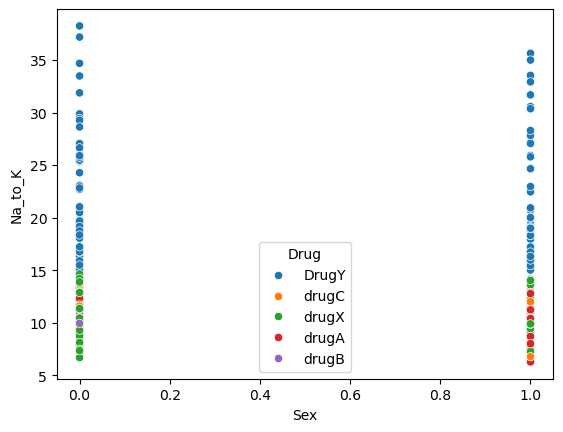

In [14]:
sns.scatterplot(x=df["Sex"], y=df["Na_to_K"], hue=df["Drug"])
plt.show()

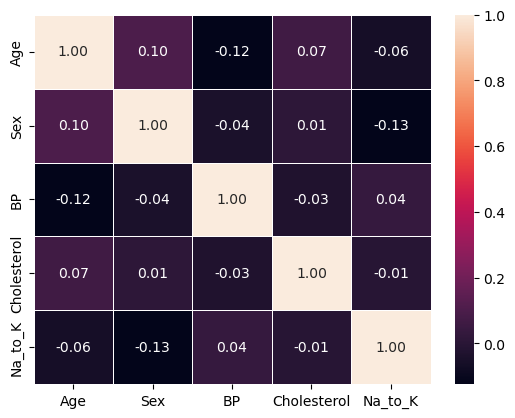

In [15]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(
    corr_matrix,
    annot=True,      
    fmt=".2f",       
    linewidths=0.5
)
plt.show()

In [16]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,2,1,25.355,DrugY
1,47,1,0,1,13.093,drugC
2,47,1,0,1,10.114,drugC
3,28,0,1,1,7.798,drugX
4,61,0,0,1,18.043,DrugY


In [17]:
X = df.drop('Drug', axis = 1).values
y = df['Drug'].values

In [18]:
X

array([[23.   ,  0.   ,  2.   ,  1.   , 25.355],
       [47.   ,  1.   ,  0.   ,  1.   , 13.093],
       [47.   ,  1.   ,  0.   ,  1.   , 10.114],
       [28.   ,  0.   ,  1.   ,  1.   ,  7.798],
       [61.   ,  0.   ,  0.   ,  1.   , 18.043],
       [22.   ,  0.   ,  1.   ,  1.   ,  8.607],
       [49.   ,  0.   ,  1.   ,  1.   , 16.275],
       [41.   ,  1.   ,  0.   ,  1.   , 11.037],
       [60.   ,  1.   ,  1.   ,  1.   , 15.171],
       [43.   ,  1.   ,  0.   ,  0.   , 19.368],
       [47.   ,  0.   ,  0.   ,  1.   , 11.767],
       [34.   ,  0.   ,  2.   ,  0.   , 19.199],
       [43.   ,  1.   ,  0.   ,  1.   , 15.376],
       [74.   ,  0.   ,  0.   ,  1.   , 20.942],
       [50.   ,  0.   ,  1.   ,  1.   , 12.703],
       [16.   ,  0.   ,  2.   ,  0.   , 15.516],
       [69.   ,  1.   ,  0.   ,  0.   , 11.455],
       [43.   ,  1.   ,  2.   ,  1.   , 13.972],
       [23.   ,  1.   ,  0.   ,  1.   ,  7.298],
       [32.   ,  0.   ,  2.   ,  0.   , 25.974],
       [57.   ,  1. 

In [19]:
y

array(['DrugY', 'drugC', 'drugC', 'drugX', 'DrugY', 'drugX', 'DrugY',
       'drugC', 'DrugY', 'DrugY', 'drugC', 'DrugY', 'DrugY', 'DrugY',
       'drugX', 'DrugY', 'drugX', 'drugA', 'drugC', 'DrugY', 'DrugY',
       'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX',
       'DrugY', 'DrugY', 'drugX', 'drugB', 'drugX', 'DrugY', 'drugX',
       'drugX', 'drugA', 'drugX', 'drugX', 'drugX', 'DrugY', 'drugB',
       'DrugY', 'drugX', 'drugX', 'drugX', 'drugA', 'drugC', 'DrugY',
       'DrugY', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugB', 'drugC',
       'drugB', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'drugA', 'DrugY',
       'drugX', 'drugB', 'DrugY', 'drugA', 'drugX', 'DrugY', 'DrugY',
       'drugB', 'DrugY', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'drugA',
       'DrugY', 'drugA', 'drugX', 'drugB', 'drugX', 'drugC', 'drugA',
       'drugC', 'drugB', 'drugX', 'DrugY', 'DrugY', 'DrugY', 'DrugY',
       'DrugY', 'DrugY', 'DrugY', 'DrugY', 'drugX', 'DrugY', 'DrugY',
       'DrugY', 'Dru

In [20]:
le_drug = LabelEncoder()
y = le_drug.fit_transform(y)

In [21]:
y

array([0, 3, 3, 4, 0, 4, 0, 3, 0, 0, 3, 0, 0, 0, 4, 0, 4, 1, 3, 0, 0, 0,
       0, 0, 0, 0, 0, 4, 0, 0, 4, 2, 4, 0, 4, 4, 1, 4, 4, 4, 0, 2, 0, 4,
       4, 4, 1, 3, 0, 0, 0, 4, 0, 0, 2, 3, 2, 0, 4, 0, 0, 1, 0, 4, 2, 0,
       1, 4, 0, 0, 2, 0, 4, 0, 0, 0, 1, 0, 1, 4, 2, 4, 3, 1, 3, 2, 4, 0,
       0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 1, 1, 3, 4, 0, 4, 4, 0, 2, 0,
       1, 4, 4, 4, 4, 0, 4, 4, 1, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0, 4, 0, 0,
       4, 0, 0, 4, 2, 1, 2, 4, 1, 0, 2, 0, 1, 4, 4, 1, 4, 3, 1, 2, 4, 4,
       0, 3, 1, 0, 3, 4, 4, 2, 4, 0, 0, 0, 0, 4, 0, 1, 4, 4, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 4, 4, 0, 0, 0, 2, 1, 0, 0, 0, 1, 0, 3, 0, 3, 3, 4,
       4, 4])

In [43]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [53]:
X_train = torch.tensor(X_train , dtype=torch.float32)
X_test = torch.tensor(X_test , dtype=torch.float32)

y_train = torch.tensor(y_train , dtype=torch.long)
y_test = torch.tensor(y_test , dtype=torch.long)

In [67]:
X_train.shape, X_test.shape ,y_train.shape, y_test.shape

(torch.Size([160, 5]),
 torch.Size([40, 5]),
 torch.Size([160]),
 torch.Size([40]))

In [83]:
from torch import nn
class DrugClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=5, out_features=16),
            nn.ReLU(),

            nn.Linear(in_features=16, out_features=16),
            nn.ReLU(),

            nn.Linear(16, 5)
        )

    def forward(self,x):
        return self.layer_stack(x)

In [107]:
model = DrugClassifier()
model = torch.compile(model)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model.parameters(), lr = 0.01)

In [109]:
model(X_test)[:5]

tensor([[ 1.1005, -3.5265, -3.3203,  1.6175,  1.2445],
        [ 0.7585, -2.1707, -2.0547,  0.9201,  0.8761],
        [ 1.1938, -4.9322, -4.9629,  2.5294,  1.8141],
        [ 1.7557, -2.6449, -1.5652, -0.1033,  0.9540],
        [ 0.6405, -3.8853, -4.3900,  2.5211,  1.5837]],
       grad_fn=<SliceBackward0>)

In [111]:
model(X_test)[0].shape

torch.Size([5])

In [113]:
y_logits = model(X_test)
y_pred_probs = torch.softmax(y_logits, dim=1) 
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 1.1005, -3.5265, -3.3203,  1.6175,  1.2445],
        [ 0.7585, -2.1707, -2.0547,  0.9201,  0.8761],
        [ 1.1938, -4.9322, -4.9629,  2.5294,  1.8141],
        [ 1.7557, -2.6449, -1.5652, -0.1033,  0.9540],
        [ 0.6405, -3.8853, -4.3900,  2.5211,  1.5837]],
       grad_fn=<SliceBackward0>)
tensor([[2.5949e-01, 2.5388e-03, 3.1202e-03, 4.3517e-01, 2.9968e-01],
        [2.9295e-01, 1.5654e-02, 1.7581e-02, 3.4432e-01, 3.2949e-01],
        [1.5001e-01, 3.2784e-04, 3.1792e-04, 5.7041e-01, 2.7893e-01],
        [6.0504e-01, 7.4238e-03, 2.1854e-02, 9.4278e-02, 2.7140e-01],
        [9.8591e-02, 1.0673e-03, 6.4433e-04, 6.4650e-01, 2.5320e-01]],
       grad_fn=<SliceBackward0>)


In [115]:
torch.sum(y_pred_probs[0])

tensor(1., grad_fn=<SumBackward0>)

In [117]:
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.2595, 0.0025, 0.0031, 0.4352, 0.2997], grad_fn=<SelectBackward0>)
tensor(3)


In [119]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() 
    acc = (correct / len(y_pred)) * 100 
    return acc

In [121]:
epochs = 300

# let's also try to plot loss - accuracy later on (totally optional)
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    ### TRAIN ###
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    #pred = torch.argmax(logits, dim=1) (we can get preds like this or the line below. cross entropy loss already containts softmax calculation so it won't change the outcome)
    pred = torch.softmax(logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    ### TEST ###
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = calculate_accuracy(y_test, test_pred)

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.9317 | Acc: 33.75% | Test Loss: 1.5221 | Test Acc: 47.50%
Epoch 20 | Loss: 1.0547 | Acc: 55.00% | Test Loss: 0.9981 | Test Acc: 60.00%
Epoch 40 | Loss: 0.9577 | Acc: 58.13% | Test Loss: 0.9041 | Test Acc: 62.50%
Epoch 60 | Loss: 0.8685 | Acc: 60.00% | Test Loss: 0.8422 | Test Acc: 62.50%
Epoch 80 | Loss: 0.7350 | Acc: 70.62% | Test Loss: 0.7231 | Test Acc: 70.00%
Epoch 100 | Loss: 0.5594 | Acc: 78.12% | Test Loss: 0.5478 | Test Acc: 80.00%
Epoch 120 | Loss: 0.4055 | Acc: 91.25% | Test Loss: 0.4048 | Test Acc: 87.50%
Epoch 140 | Loss: 0.2938 | Acc: 90.00% | Test Loss: 0.3075 | Test Acc: 92.50%
Epoch 160 | Loss: 0.2242 | Acc: 95.00% | Test Loss: 0.2394 | Test Acc: 95.00%
Epoch 180 | Loss: 0.1782 | Acc: 95.62% | Test Loss: 0.1915 | Test Acc: 97.50%
Epoch 200 | Loss: 0.1454 | Acc: 96.88% | Test Loss: 0.1570 | Test Acc: 97.50%
Epoch 220 | Loss: 0.1207 | Acc: 96.88% | Test Loss: 0.1349 | Test Acc: 100.00%
Epoch 240 | Loss: 0.1055 | Acc: 98.12% | Test Loss: 0.1294 | Test Acc

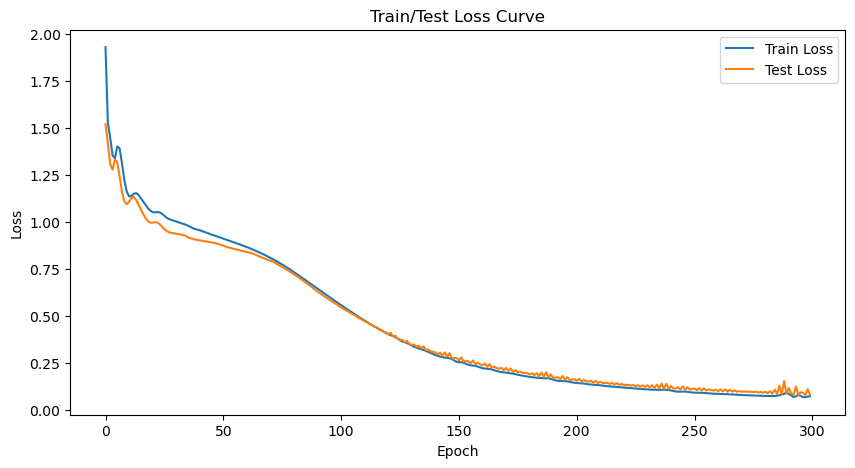

In [123]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Test Loss Curve")
plt.legend()
plt.show()

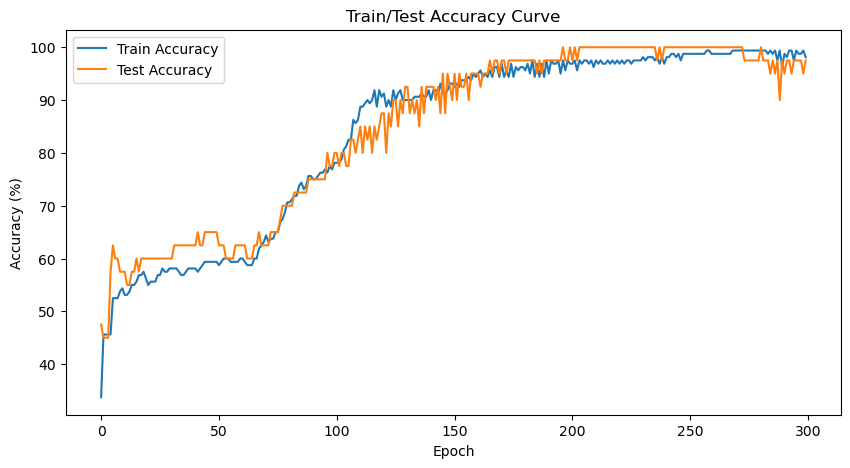

In [125]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train/Test Accuracy Curve")
plt.legend()
plt.show()

In [129]:
new_sample = np.array([[23, 0, 2, 1,25.355]])
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [131]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()

In [133]:
predicted_label = le_drug.inverse_transform([predicted_class])[0]

In [135]:
print("Predicted Class Index:", predicted_class)
print("Predicted Species:", predicted_label)

Predicted Class Index: 0
Predicted Species: DrugY


In [137]:
# torchmetrics

In [139]:
from torchmetrics.classification import MulticlassAccuracy
accuracy = MulticlassAccuracy(num_classes=5)

In [153]:
epochs = 200
model2 = DrugClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)
for epoch in range(epochs):
    model2.train()
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.argmax(logits, dim=1)
    acc = accuracy(pred, y_train).item() * 100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### TEST ###
    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.argmax(test_logits, dim=1)
        test_acc = accuracy(test_pred, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 4.9181 | Acc: 23.33% | Test Loss: 2.7930 | Test Acc: 24.00%
Epoch 20 | Loss: 1.1349 | Acc: 24.65% | Test Loss: 1.0771 | Test Acc: 27.27%
Epoch 40 | Loss: 1.0116 | Acc: 30.18% | Test Loss: 0.9731 | Test Acc: 34.14%
Epoch 60 | Loss: 0.9263 | Acc: 39.41% | Test Loss: 0.8835 | Test Acc: 46.77%
Epoch 80 | Loss: 0.7771 | Acc: 50.07% | Test Loss: 0.7381 | Test Acc: 54.77%
Epoch 100 | Loss: 0.6020 | Acc: 68.48% | Test Loss: 0.5690 | Test Acc: 69.43%
Epoch 120 | Loss: 0.4782 | Acc: 78.25% | Test Loss: 0.4566 | Test Acc: 77.21%
Epoch 140 | Loss: 0.3844 | Acc: 90.43% | Test Loss: 0.3867 | Test Acc: 79.03%
Epoch 160 | Loss: 0.3117 | Acc: 92.16% | Test Loss: 0.3188 | Test Acc: 85.70%
Epoch 180 | Loss: 0.2506 | Acc: 94.94% | Test Loss: 0.2514 | Test Acc: 98.18%


In [155]:
from torchmetrics.classification import MulticlassConfusionMatrix
cm = MulticlassConfusionMatrix(num_classes=5)
matrix = cm(test_pred, y_test)

In [159]:
print(matrix)

tensor([[18,  0,  0,  0,  0],
        [ 0,  5,  0,  0,  0],
        [ 0,  0,  3,  0,  0],
        [ 0,  0,  0,  2,  1],
        [ 0,  0,  0,  0, 11]])


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

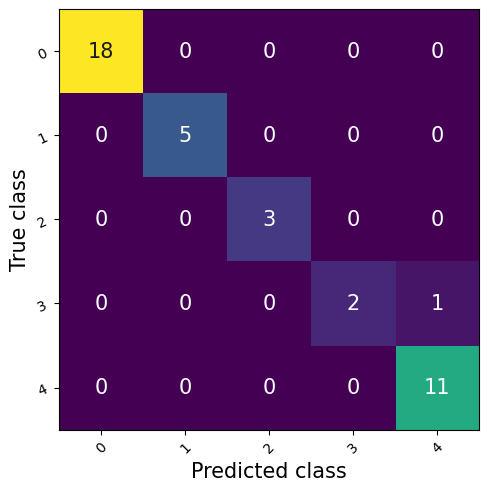

In [161]:
from torchmetrics.utilities.plot import plot_confusion_matrix
plot_confusion_matrix(matrix)

In [163]:
from pathlib import Path

In [166]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "drug_classification.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model2.state_dict(), f=MODEL_SAVE_PATH)

In [168]:
model2.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 1.0516e-01,  3.5340e-01, -1.8399e+00,  6.5289e-01,  3.4960e-01],
                      [-2.2210e-02, -8.7996e-03,  1.0943e+00,  8.7187e-03,  3.9137e-01],
                      [-3.9358e-01,  2.6759e-01,  2.8539e-02, -9.0096e-02, -3.1963e-01],
                      [ 1.3800e-01,  1.4519e-01, -9.2138e-01,  2.1463e-01,  3.8293e-01],
                      [ 2.6280e-01, -8.2244e-01,  5.3159e-01, -1.2214e-01, -5.2783e-01],
                      [-3.9999e-01, -1.8034e-01,  3.4990e-01,  1.3229e-01, -2.6154e-01],
                      [ 3.8550e-01,  1.1887e-01,  9.8621e-01,  1.0342e-01,  3.3562e-01],
                      [-1.7931e-01,  8.6210e-02, -2.9661e-01,  7.4707e-02, -1.8243e-01],
                      [ 3.6074e-01, -3.3582e-01,  1.6826e+00,  5.1318e-01, -3.3645e-01],
                      [ 2.7888e-01, -1.4956e+00, -5.6639e-01, -5.1036e-01, -3.7396e-01],
                      [-2.4920e-02,  1.1443e+00,  2.2099e-01, -2.1236e+0

In [170]:
loaded_model = DrugClassifier()

In [172]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [174]:
new_sample = np.array([[23, 0, 2, 1,25.355]])
new_sample_tensor = torch.tensor(new_sample, dtype = torch.float32)
loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim = 1)
    predicted_class = torch.argmax(probs, dim=1).item()
le_drug.inverse_transform([predicted_class])[0]

'DrugY'